In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    cohen_kappa_score
)


In [ ]:
df = pd.read_csv("/content/alzheimers_disease_data.csv")

TARGET = "Diagnosis"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

if "DoctorInCharge" in X.columns:
    X = X.drop("DoctorInCharge", axis=1)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP (ANN)": MLPClassifier(max_iter=500, random_state=42)
}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": calculate_specificity(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Accuracy,Recall (Sensitivity),Specificity,Precision,F1-score,Kappa,AUC
Logistic Regression,0.816279,0.743421,0.856115,0.738562,0.740984,0.598644,0.889814
SVM,0.869767,0.789474,0.913669,0.833333,0.810811,0.711631,0.939654
KNN,0.830233,0.756579,0.870504,0.761589,0.759076,0.628019,0.903469
Decision Tree,0.953488,0.960526,0.949640,0.912500,0.935897,0.899439,0.955083
Random Forest,0.955814,0.934211,0.967626,0.940397,0.937294,0.903183,0.988191
AdaBoost,0.925581,0.894737,0.942446,0.894737,0.894737,0.837183,0.946150
Gradient Boosting,0.955814,0.947368,0.960432,0.929032,0.938111,0.903758,0.983067
MLP (ANN),0.879070,0.842105,0.899281,0.820513,0.831169,0.736991,0.950043


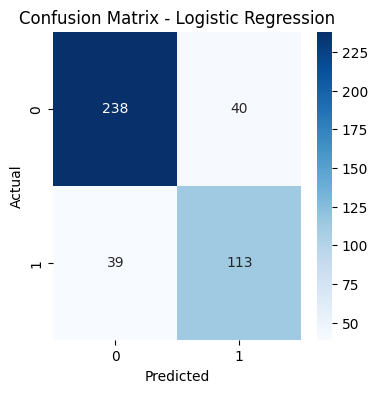

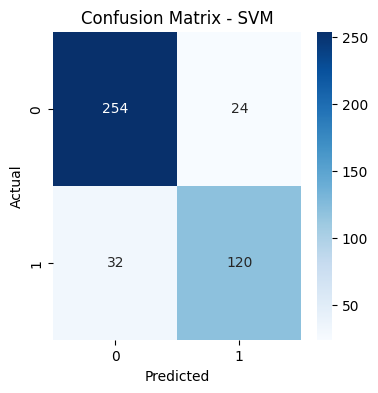

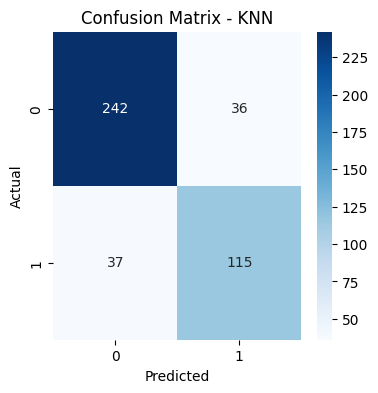

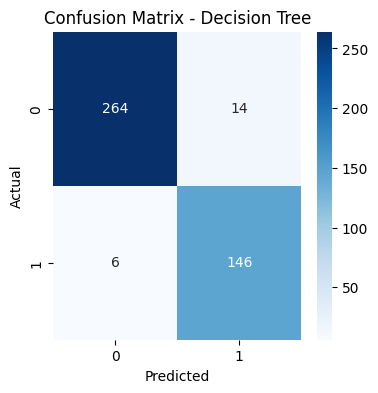

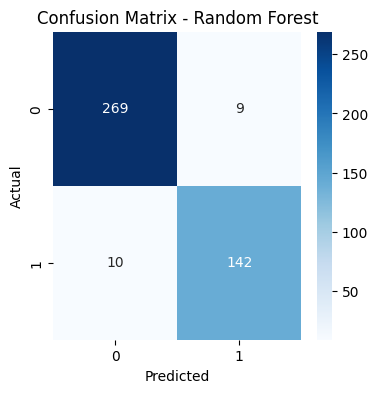

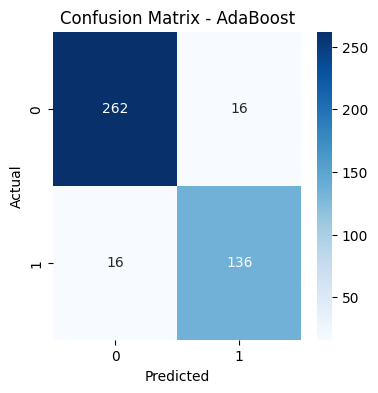

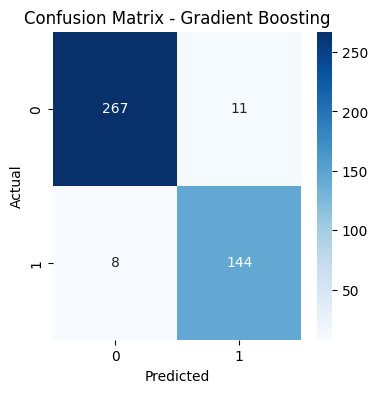

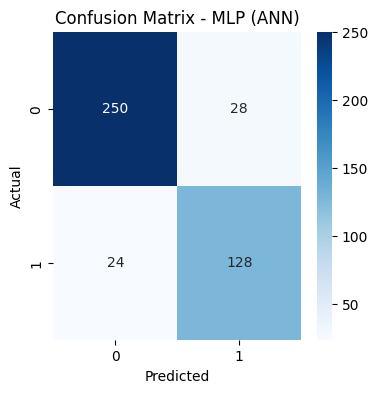

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


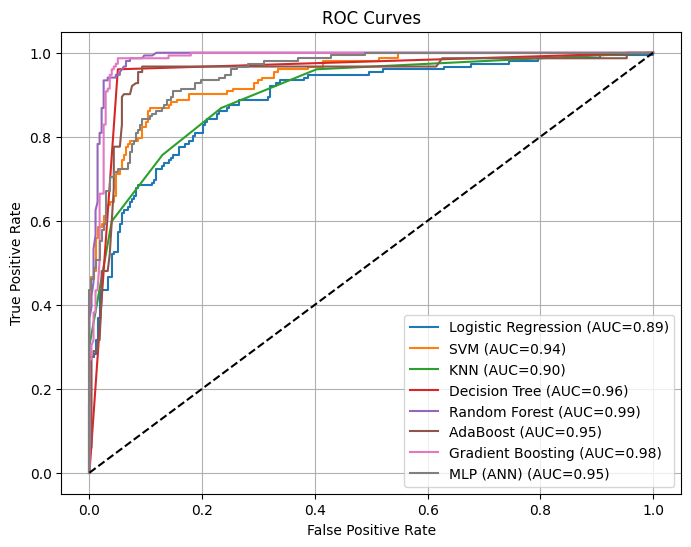

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    y_pred_cv = cross_val_predict(model, X_selected, y, cv=cv)
    y_prob_cv = cross_val_predict(
        model, X_selected, y, cv=cv, method="predict_proba"
    )[:,1]

    cv_results[name] = {
        "Accuracy": accuracy_score(y, y_pred_cv),
        "Recall": recall_score(y, y_pred_cv),
        "Specificity": calculate_specificity(y, y_pred_cv),
        "Precision": precision_score(y, y_pred_cv),
        "F1": f1_score(y, y_pred_cv),
        "Kappa": cohen_kappa_score(y, y_pred_cv),
        "AUC": roc_auc_score(y, y_prob_cv)
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

,Accuracy,Recall,Specificity,Precision,F1,Kappa,AUC
Logistic Regression,0.844579,0.742105,0.900648,0.803419,0.771546,0.654055,0.902821
SVM,0.878548,0.786842,0.928726,0.857963,0.820865,0.729255,0.943427
KNN,0.857143,0.778947,0.899928,0.809850,0.794098,0.684792,0.911757
Decision Tree,0.949279,0.925000,0.962563,0.931126,0.928053,0.888887,0.943781
Random Forest,0.952536,0.923684,0.968323,0.941019,0.932271,0.895743,0.989652
AdaBoost,0.933923,0.914474,0.944564,0.900259,0.907311,0.855978,0.955235
Gradient Boosting,0.954863,0.943421,0.961123,0.929961,0.936643,0.901590,0.982729
MLP (ANN),0.897627,0.840789,0.928726,0.865854,0.853138,0.774592,0.958117


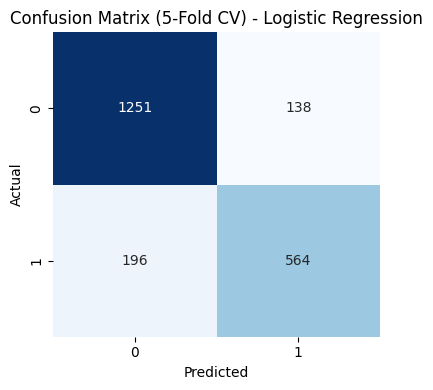

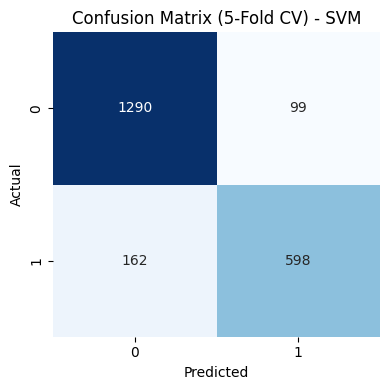

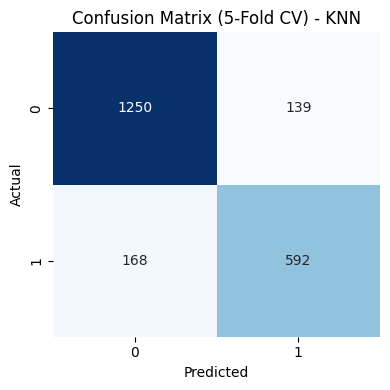

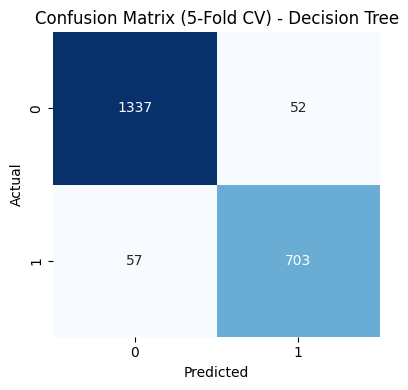

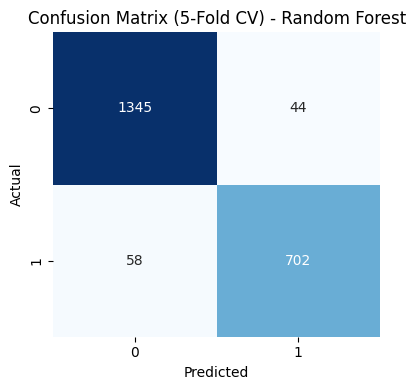

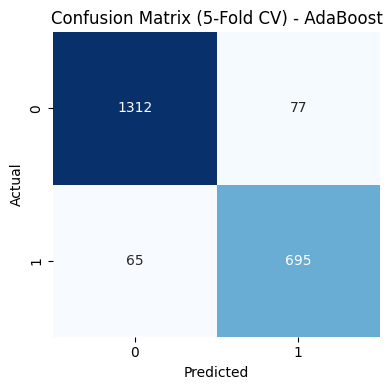

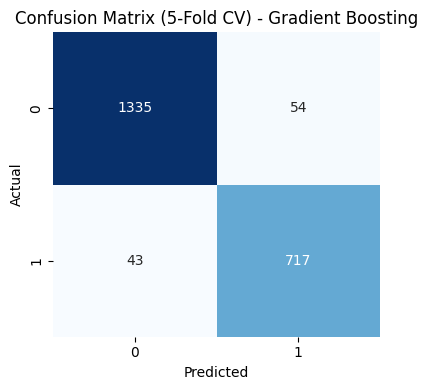

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

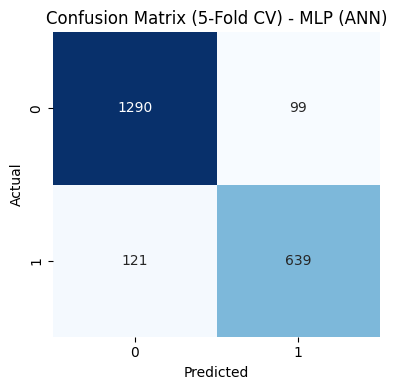

In [ ]:
for name, model in models.items():
    y_pred_cv = cross_val_predict(
        model, X_selected, y, cv=cv, method="predict"
    )

    cm = confusion_matrix(y, y_pred_cv)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix (5-Fold CV) - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

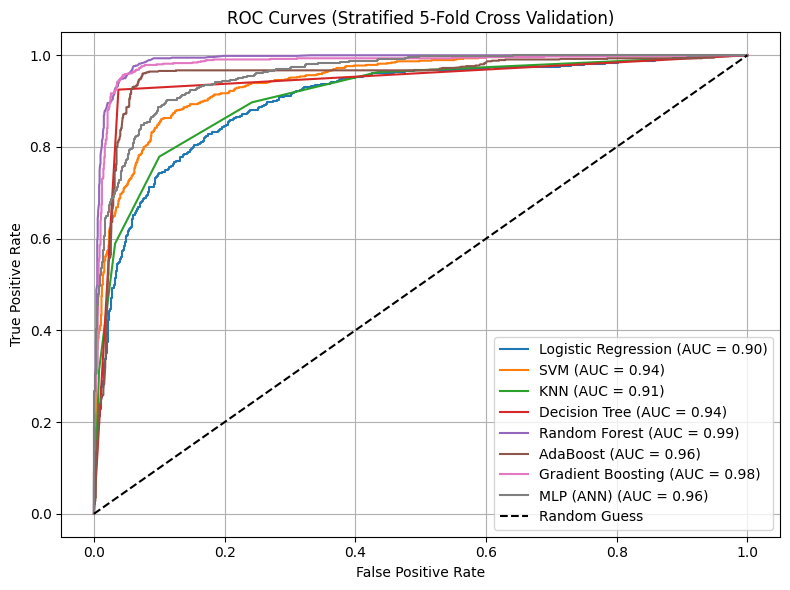

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob_cv = cross_val_predict(
            model,
            X_selected,
            y,
            cv=cv,
            method="predict_proba"
        )[:, 1]

        fpr, tpr, _ = roc_curve(y, y_prob_cv)
        auc = roc_auc_score(y, y_prob_cv)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Rastgele sınıflandırıcı çizgisi
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Stratified 5-Fold Cross Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
